In [1]:
import sys
!{sys.executable} -m pip install tensorflow


[notice] A new release of pip is available: 25.0.1 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import sys
!{sys.executable} -m pip install matplotlib


[notice] A new release of pip is available: 25.0.1 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import matplotlib.pyplot as plt
import numpy as np
import PIL
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Conv2D,MaxPooling2D,Flatten,Dropout

In [4]:
test_dir=r"C:\Users\ELCOT\Documents\data  set\archive\Grapevine_Leaves_Image_Dataset"

In [5]:
ds_train = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='int',
    batch_size=8,
    image_size=(224, 224),
    shuffle=True
)  

Found 500 files belonging to 5 classes.


In [6]:
class_names = ds_train.class_names
print(class_names) 

['Ak', 'Ala_Idris', 'Buzgulu', 'Dimnit', 'Nazli']


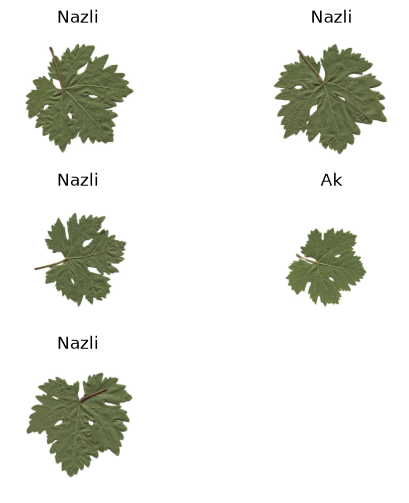

{'class_names': ['Ak', 'Ala_Idris', 'Buzgulu', 'Dimnit', 'Nazli'], 'sample_batch_shape': TensorShape([8, 224, 224, 3])}
{'class_names': ['Ak', 'Ala_Idris', 'Buzgulu', 'Dimnit', 'Nazli'], 'sample_batch_shape': TensorShape([8, 224, 224, 3])}


In [7]:
images, labels = next(iter(ds_train))
plt.figure(figsize=(6,6))
for i in range(5):
    ax = plt.subplot(3, 2, i+1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[int(labels[i])])
    plt.axis("off")
ds_info = {"class_names": class_names, "sample_batch_shape": images.shape}
plt.show()
print(ds_info)
print(ds_info)

In [8]:
IMG_HEIGHT = 220
IMG_WIDTH = 220
BATCH_SIZE = 8

def preprocess_image(image, label): 
  image = tf.image.resize(image, (IMG_HEIGHT, IMG_WIDTH))
  image = tf.cast(image, tf.float32) / 255.0  
  return image, label

ds_processed = ds_train.map(preprocess_image)

DATASET_SIZE = tf.data.experimental.cardinality(ds_train.unbatch()).numpy()
train_size = int(0.8 * DATASET_SIZE)
val_size = DATASET_SIZE - train_size 

AUTOTUNE = tf.data.AUTOTUNE  
ds_shuffled = ds_processed.shuffle(buffer_size=DATASET_SIZE, seed=123)                                          

train_ds = ds_shuffled.take(train_size).batch(BATCH_SIZE).cache().prefetch(buffer_size=AUTOTUNE)
val_ds = ds_shuffled.skip(train_size).batch(BATCH_SIZE).cache().prefetch(buffer_size=AUTOTUNE)
print(f"Number of training batches: {len(train_ds)}")
print(f"Number of validation batches: {len(val_ds)}")

Number of training batches: 8
Number of validation batches: 0


In [9]:
class_names=ds_info['class_names']
print(class_names)

['Ak', 'Ala_Idris', 'Buzgulu', 'Dimnit', 'Nazli']


In [10]:
len(class_names)

5

In [11]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='int',
    batch_size=BATCH_SIZE,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    shuffle=True,
    validation_split=0.2,
    subset='training',
    seed=123
)

Found 500 files belonging to 5 classes.
Using 400 files for training.


In [12]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='int',
    batch_size=BATCH_SIZE,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    shuffle=True,
    validation_split=0.2,
    subset='validation',
    seed=123
)

Found 500 files belonging to 5 classes.
Using 100 files for validation.


In [ ]:
model = Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.2),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(5, activation='softmax')
])

c:\Users\ELCOT\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [15]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)
history = model.fit(train_ds, validation_data=val_ds, epochs=10)

Epoch 1/10


50/50 ━━━━━━━━━━━━━━━━━━━━ 20s 366ms/step - accuracy: 0.2100 - loss: 2.2882 - val_accuracy: 0.1600 - val_loss: 2.0753
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 18s 366ms/step - accuracy: 0.2050 - loss: 1.9905 - val_accuracy: 0.1600 - val_loss: 1.9243
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 18s 359ms/step - accuracy: 0.2100 - loss: 1.8417 - val_accuracy: 0.1600 - val_loss: 1.7778
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 16s 328ms/step - accuracy: 0.1925 - loss: 1.7277 - val_accuracy: 0.1600 - val_loss: 1.7017
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 16s 310ms/step - accuracy: 0.2100 - loss: 1.6741 - val_accuracy: 0.1600 - val_loss: 1.6698
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 15s 305ms/step - accuracy: 0.2100 - loss: 1.6480 - val_accuracy: 0.1600 - val_loss: 1.6549
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 17s 330ms/step - accuracy: 0.2100 - loss: 1.6359 - val_accuracy: 0.1600 - val_loss: 1.6453
Epoch 8/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 16s 314ms/step - accuracy: 0.1725 - loss: 1.6292 - val_accuracy: 0.160

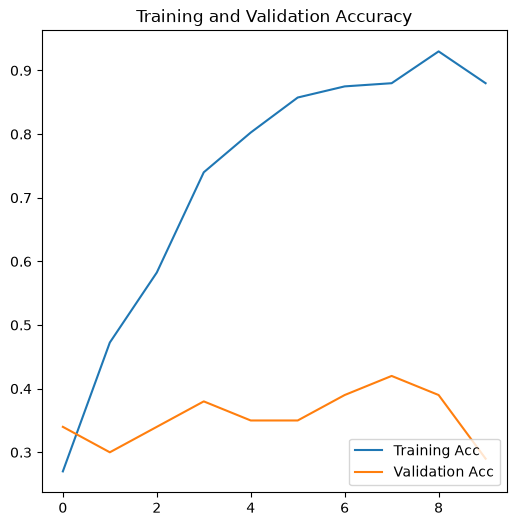

In [ ]:
import matplotlib.pyplot as plt
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
epochs_range = range(len(acc))
plt.figure(figsize=(6,6))
plt.plot(epochs_range, acc, label='Training Acc')
plt.plot(epochs_range, val_acc, label='Validation Acc')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.show()

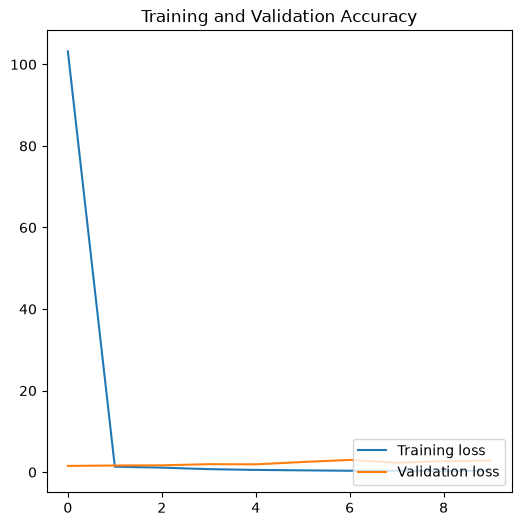

In [ ]:
acc = history.history['loss']
val_acc = history.history['val_loss']
epochs_range = range(len(acc))
plt.figure(figsize=(6,6))
plt.plot(epochs_range, acc, label='Training loss')
plt.plot(epochs_range, val_acc, label='Validation loss')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.show()

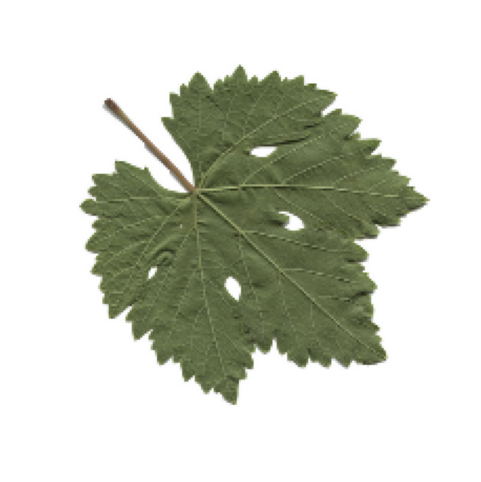

In [ ]:
plt.figure(figsize=(6, 6))

for images, labels in train_ds.take(1):
    img = images[7].numpy()
    if img.max() > 1.0:
        img = img.astype("uint8")
    else:
        img = np.clip(img, 0, 1)

    plt.imshow(img)
    plt.axis('off')
    plt.show()
    break

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [20.6002..255.0].


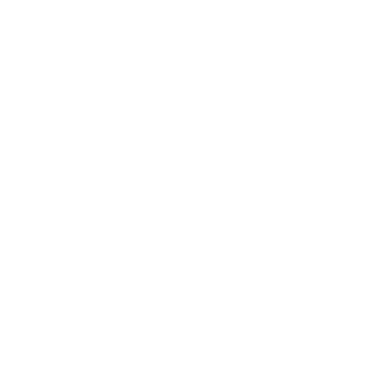

In [ ]:
plt.axis('off')
for images, labels in train_ds.take(1):
    plt.imshow(images[3])
    break

In [ ]:
data_augmentation=Sequential([
    layers.RandomFlip('vertical'),
    layers.RandomRotation(0.5),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.1,0.1),
    layers.RandomContrast(0.4),
    layers.RandomBrightness(0.0),])

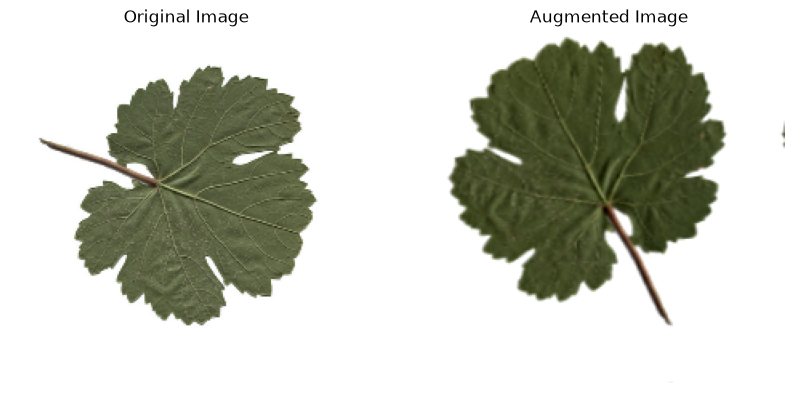

In [ ]:
plt.figure(figsize=(10, 5))
for images, labels in train_ds.take(1):
    first_image = images[0]
    augmented_image = data_augmentation(tf.expand_dims(first_image, 0))
    plt.subplot(1, 2, 1)
    plt.imshow(first_image.numpy().astype("uint8"))
    plt.title("Original Image")
    plt.axis("off")
    plt.subplot(1, 2, 2)
    plt.imshow(tf.squeeze(augmented_image).numpy().astype("uint8"))
    plt.title("Augmented Image")
    plt.axis("off")
    break 
plt.show()

In [ ]:
pred=model.predict(val_ds)
pred

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 125ms/step


array([[1.05730328e-03, 1.22314668e-03, 3.54230491e-04, 2.63630727e-06,
        9.97362673e-01, 2.61847037e-11, 1.92166519e-10, 6.46406973e-12,
        2.75472648e-11],
       [1.69762932e-02, 6.43450257e-05, 7.69385397e-01, 2.08752245e-01,
        4.81784809e-03, 9.66285008e-09, 2.50580547e-06, 1.00341117e-06,
        4.54626615e-07],
       [3.06641102e-01, 3.68661955e-02, 5.60070038e-01, 1.36101944e-03,
        9.49647948e-02, 1.89375356e-07, 8.59588763e-05, 1.23823384e-06,
        9.52918708e-06],
       [3.63980792e-03, 1.21392508e-03, 3.23034497e-03, 3.62753198e-02,
        9.55639482e-01, 2.74336411e-08, 1.05717800e-06, 7.55432836e-08,
        1.89580085e-09],
       [1.61216445e-02, 3.65316235e-02, 8.56835842e-01, 9.01453421e-02,
        3.65053304e-04, 6.04328187e-09, 8.59666400e-08, 9.00996469e-08,
        2.40095090e-07],
       [1.66814047e-04, 9.90748942e-01, 1.84245975e-04, 6.67091401e-04,
        8.23288038e-03, 1.97810067e-11, 3.87114729e-10, 2.94612370e-08,
        2.9

In [ ]:
sc=tf.nn.softmax(pred)
sc

<tf.Tensor: shape=(100, 9), dtype=float32, numpy=
array([[0.09343664, 0.09345214, 0.09337097, 0.09333815, 0.25305045,
        0.0933379 , 0.0933379 , 0.0933379 , 0.0933379 ],
       [0.09768179, 0.09604369, 0.20729114, 0.11833162, 0.09650132,
        0.09603751, 0.09603775, 0.0960376 , 0.09603756],
       [0.13259327, 0.10124177, 0.17083792, 0.09771022, 0.107298  ,
        0.09757735, 0.09758571, 0.09757745, 0.09757826],
       [0.09428007, 0.09405164, 0.09424148, 0.09740771, 0.24426886,
        0.09393754, 0.09393764, 0.09393755, 0.09393754],
       [0.09675042, 0.09874539, 0.22426963, 0.10418399, 0.09523792,
        0.09520315, 0.09520316, 0.09520317, 0.09520318],
       [0.09345138, 0.251646  , 0.09345301, 0.09349816, 0.09420822,
        0.0934358 , 0.0934358 , 0.0934358 , 0.0934358 ],
       [0.09699213, 0.09712053, 0.20525514, 0.10011286, 0.11570603,
        0.09620193, 0.09620222, 0.09620709, 0.09620214],
       [0.09339027, 0.09339309, 0.25238773, 0.09368896, 0.09360293,
       

In [ ]:
np.argmax(sc)

np.int64(631)